In [1]:
import numpy as np
import pandas as pd
import os

np.random.seed(42)

os.makedirs("../data/raw", exist_ok=True)

timestamps = pd.date_range(
    start="2025-01-01",
    periods=60 * 24 * 12,
    freq="5min"
)

df = pd.DataFrame({
    "timestamp": timestamps
})

df["hour"] = df["timestamp"].dt.hour
df["minute"] = df["timestamp"].dt.minute
df["day_of_week"] = df["timestamp"].dt.dayofweek
df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)

time_in_hours = df["hour"] + df["minute"] / 60

base_ns = 8
base_ew = 6

morning_peak_ns = 35 * np.exp(-0.5 * ((time_in_hours - 8) / 1.5) ** 2)
morning_peak_ew = 25 * np.exp(-0.5 * ((time_in_hours - 8) / 1.5) ** 2)

evening_peak_ns = 30 * np.exp(-0.5 * ((time_in_hours - 17) / 2) ** 2)
evening_peak_ew = 40 * np.exp(-0.5 * ((time_in_hours - 17) / 2) ** 2)

weekend_factor = np.where(df["is_weekend"] == 1, 0.70, 1.0)

noise_ns = np.random.normal(0, 4, len(df))
noise_ew = np.random.normal(0, 4, len(df))

df["ns_vehicle_count"] = (
    (base_ns + morning_peak_ns + evening_peak_ns) * weekend_factor + noise_ns
)

df["ew_vehicle_count"] = (
    (base_ew + morning_peak_ew + evening_peak_ew) * weekend_factor + noise_ew
)

df["ns_vehicle_count"] = df["ns_vehicle_count"].clip(lower=0).round().astype(int)
df["ew_vehicle_count"] = df["ew_vehicle_count"].clip(lower=0).round().astype(int)

df = df[
    [
        "timestamp",
        "hour",
        "minute",
        "day_of_week",
        "is_weekend",
        "ns_vehicle_count",
        "ew_vehicle_count"
    ]
]

df.to_csv("../data/raw/traffic_data.csv", index=False)

df.head()

,timestamp,hour,minute,day_of_week,is_weekend,ns_vehicle_count,ew_vehicle_count
0,2025-01-01 00:00:00,0,0,2,0,10,7
1,2025-01-01 00:05:00,0,5,2,0,7,8
2,2025-01-01 00:10:00,0,10,2,0,11,8
3,2025-01-01 00:15:00,0,15,2,0,14,0
4,2025-01-01 00:20:00,0,20,2,0,7,9


In [2]:
print("Shape:", df.shape)
print("\nColumn information:")
print(df.info())
print("\nMissing values:")
print(df.isnull().sum())
print("\nStatistics:")
print(df.describe())

assert df.isnull().sum().sum() == 0
assert (df["ns_vehicle_count"] >= 0).all()
assert (df["ew_vehicle_count"] >= 0).all()
assert df["timestamp"].is_monotonic_increasing

print("\nAll data checks passed.")

Shape: (17280, 7)

Column information:
<class 'pandas.DataFrame'>
RangeIndex: 17280 entries, 0 to 17279
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   timestamp         17280 non-null  datetime64[us]
 1   hour              17280 non-null  int32         
 2   minute            17280 non-null  int32         
 3   day_of_week       17280 non-null  int32         
 4   is_weekend        17280 non-null  int64         
 5   ns_vehicle_count  17280 non-null  int64         
 6   ew_vehicle_count  17280 non-null  int64         
dtypes: datetime64[us](1), int32(3), int64(3)
memory usage: 742.6 KB
None

Missing values:
timestamp           0
hour                0
minute              0
day_of_week         0
is_weekend          0
ns_vehicle_count    0
ew_vehicle_count    0
dtype: int64

Statistics:
                 timestamp          hour        minute   day_of_week  \
count                17280  17280.0

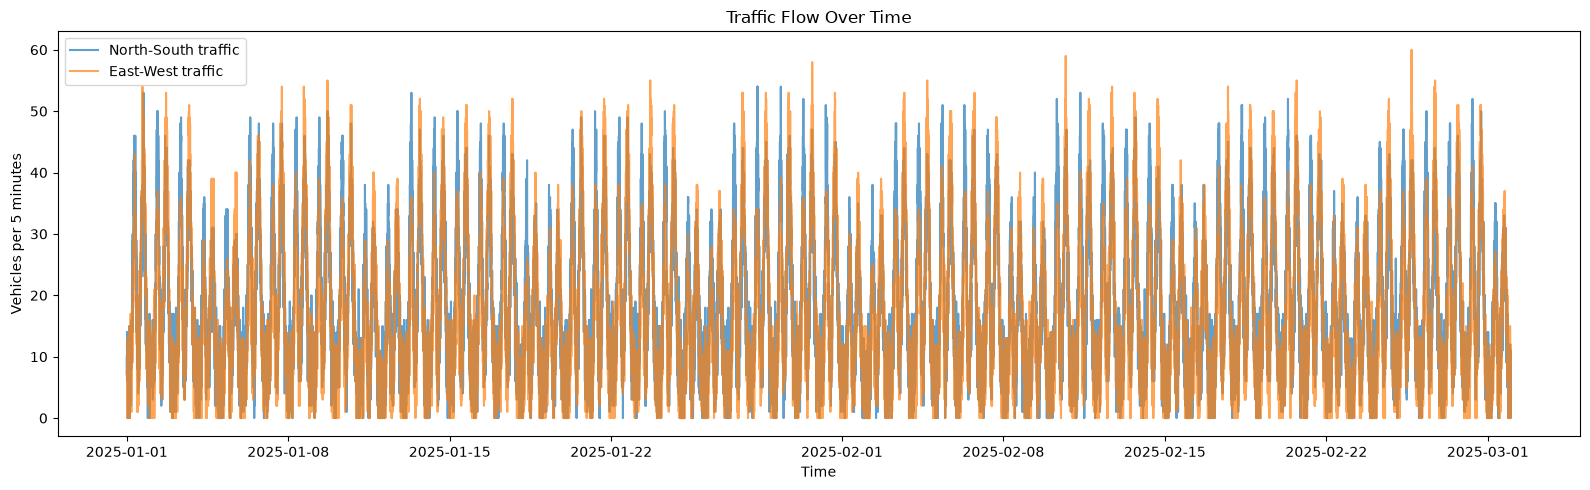

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 5))

plt.plot(df["timestamp"], df["ns_vehicle_count"], label="North-South traffic", alpha=0.7)
plt.plot(df["timestamp"], df["ew_vehicle_count"], label="East-West traffic", alpha=0.7)

plt.xlabel("Time")
plt.ylabel("Vehicles per 5 minutes")
plt.title("Traffic Flow Over Time")
plt.legend()
plt.tight_layout()

plt.savefig("../results/traffic_over_time.png")
plt.show()

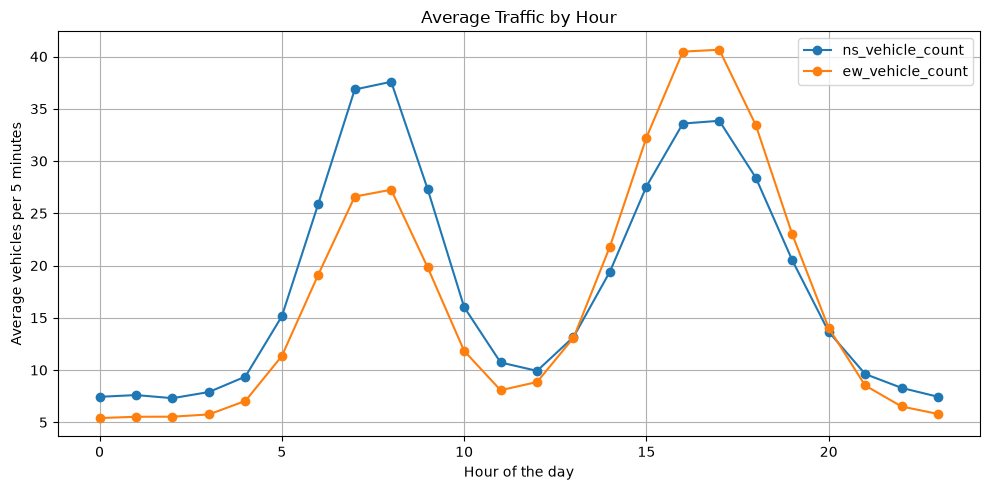

In [4]:
hourly_traffic = df.groupby("hour")[["ns_vehicle_count", "ew_vehicle_count"]].mean()

hourly_traffic.plot(figsize=(10, 5), marker="o")

plt.xlabel("Hour of the day")
plt.ylabel("Average vehicles per 5 minutes")
plt.title("Average Traffic by Hour")
plt.grid(True)
plt.tight_layout()

plt.savefig("../results/average_traffic_by_hour.png")
plt.show()